Import Libraries

In [78]:
library(ggplot2)
library(caTools)
library(dplyr)

Create Synthetic Dataset

In [79]:
set.seed(123)
n <- 1000

In [80]:
fico_score <- runif(n, 450, 850)
orig_ltv <- runif(n, 50, 120)
dti <- runif(n, 10, 65)
income <- runif(n, 30000, 175000)


In [81]:
#Create premium with realistic relationships and some noise
risk_score <- 
        (850 - fico_score) * 0.001 +
        (orig_ltv-50) * 0.0035 +
        (dti-10) * 0.007 +
        (175000-income)/1000 * 0.0001 +
        rnorm(n, 0, 0.1)  # Add this random noise


In [82]:
early_default <- ifelse(risk_score > median(risk_score)*1.25, 1, 0)

In [83]:
loan_data <- data.frame(fico_score = round(fico_score, 0), orig_ltv = round(orig_ltv, 0), dti = round(dti, 0), income = round(income, 0), early_default = early_default)

In [84]:
#Check the distribution
table(early_default)
cat("Default rate:", round(mean(early_default) * 100, 1), "%")

early_default
  0   1 
736 264 

Default rate: 26.4 %

Running Logistic Regression

In [85]:
logisticReg <- loan_data[c("fico_score", "early_default")]

In [86]:
#First, lets split our dataset between train and test
split <- sample.split(logisticReg$early_default, SplitRatio = 0.7)
trainingset <- subset(logisticReg, split == TRUE)
testset <- subset(logisticReg, split == FALSE)

In [87]:
glm_r <- glm(formula = early_default ~ fico_score, family = binomial, data=trainingset)

In [88]:
# Store for easy reference
intercept <- glm_r$coefficients[1]
fico_coef <- glm_r$coefficients[2]

cat("Intercept:", round(intercept, 2), "\n")
cat("Fico Score Coefficient:", round(fico_coef, 4), "\n")

Intercept: 6.67 
Fico Score Coefficient: -0.0126 


In [89]:
odds_ratio <- exp(fico_coef)
cat("Odds Ratio:", round(odds_ratio, 4), "\n")

Odds Ratio: 0.9875 


In [90]:
# Calculate predicted probabilities for specific FICO scores
fico_550 <- data.frame(fico_score = 550)
fico_650 <- data.frame(fico_score = 650)
fico_750 <- data.frame(fico_score = 750)

prob_550 <- predict(glm_r, newdata = fico_550, type = "response")
prob_650 <- predict(glm_r, newdata = fico_650, type = "response")
prob_750 <- predict(glm_r, newdata = fico_750, type = "response")

cat("Default probability with 550 FICO:", round(prob_550 * 100, 1), "%\n")
cat("Default probability with 650 FICO:", round(prob_650 * 100, 1), "%\n")
cat("Default probability with 750 FICO:", round(prob_750 * 100, 1), "%\n")

cat("Difference between 650-750:", round((prob_650 - prob_750) * 100, 1), "percentage points\n")
cat("650-750 Risk reduction:", round((1 - prob_750/prob_650) * 100, 1), "%\n")

cat("Difference between 550-650:", round((prob_550 - prob_650) * 100, 1), "percentage points\n")
cat("550-650 Risk reduction:", round((1 - prob_650/prob_550) * 100, 1), "%\n")

Default probability with 550 FICO: 44 %
Default probability with 650 FICO: 18.3 %
Default probability with 750 FICO: 6 %
Difference between 650-750: 12.3 percentage points
650-750 Risk reduction: 67.3 %
Difference between 550-650: 25.7 percentage points
550-650 Risk reduction: 58.5 %


In [91]:
# Create a small data frame for the specific predictions
prediction_points <- data.frame(
  fico_score = c(550, 650, 750),
  probability = c(prob_550, prob_650, prob_750),
  min_val = c(0, 0, 0),
  max_val = c(prob_550*1.5, prob_650*1.75, prob_750*2),
  labels = c(
              paste("High Risk: ",round(prob_550*100, 1),"%"),
              paste("Med Risk: ",round(prob_650*100, 1),"%"),
              paste("Low Risk: ",round(prob_750*100, 1),"%")
  )
  )

`geom_smooth()` using formula = 'y ~ x'


NULL

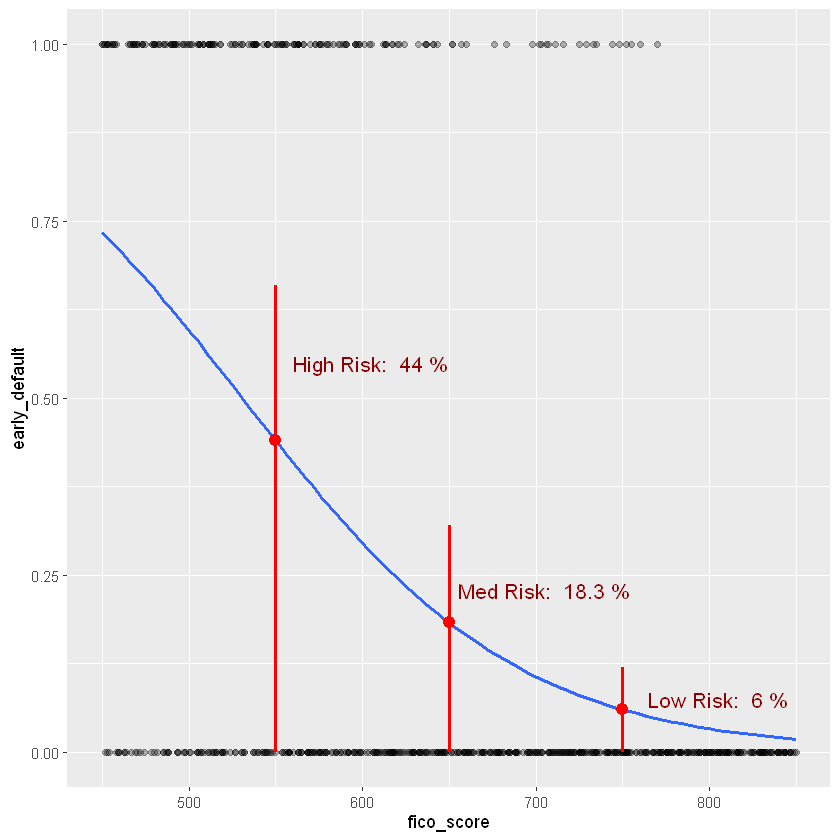

In [92]:
# Simple approach - plot your existing data with regression curve
ggplot(trainingset, aes(x = fico_score, y = early_default)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), se = FALSE) +
  geom_point(data = prediction_points, aes(x = fico_score, y = probability), 
             color = "red", size = 3) +
  # Add vertical lines from min to max values
  geom_segment(data = prediction_points, 
               aes(x = fico_score, xend = fico_score, 
                   y = min_val, yend = max_val), 
               color = "red", linewidth = 1) +
  geom_text(data=prediction_points,
            aes(x=fico_score+55, y=probability*1.25, label=labels),
            color="darkred", , size = 4.5, hjust = 0.5)
  labs(title = "Early Default Probability by FICO Score",
       x = "FICO Score",
       y = "Early Default Probability") +
  theme_minimal()

Multiple Logistic Regression

In [93]:
multLogisticReg <- loan_data

In [94]:
#First, lets split our dataset between train and test
split <- sample.split(multLogisticReg$early_default, SplitRatio = 0.7)
trainingset <- subset(multLogisticReg, split == TRUE)
testset <- subset(multLogisticReg, split == FALSE)

In [95]:
m_glm_r <- glm(formula = early_default ~ fico_score + orig_ltv + dti + income, family = binomial, data=trainingset)

In [96]:
# Extract coefficients for interpretation
intercept <- m_glm_r$coefficients[1]
fico_coef <- m_glm_r$coefficients[2]
ltv_coef <- m_glm_r$coefficients[3]
dti_coef <- m_glm_r$coefficients[4]
income_coef <- m_glm_r$coefficients[5]

cat("FICO Score Coefficient:", round(fico_coef, 4), "\n")
cat("LTV Coefficient:", round(ltv_coef, 4), "\n")
cat("DTI Coefficient:", round(dti_coef, 4), "\n")
cat("Income Coefficient:", round(income_coef, 6), "\n")

FICO Score Coefficient: -0.0199 
LTV Coefficient: 0.0536 
DTI Coefficient: 0.1123 
Income Coefficient: -1e-06 


In [117]:
# Predict for a sample borrower with both models
sample_borrower <- data.frame(fico_score = 700, orig_ltv =70, dti = 35, income = 90000)

prob_single <- predict(glm_r, newdata = sample_borrower, type = "response")
prob_multiple <- predict(m_glm_r, newdata = sample_borrower, type = "response")

cat("Single variable model prediction:", round(prob_single * 100, 1), "%\n")
cat("Multiple variable model prediction:", round(prob_multiple * 100, 1), "%\n")

Single variable model prediction: 10.6 %
Multiple variable model prediction: 1.1 %


In [122]:
# Predict for a sample borrower with both models
sample_borrower <- data.frame(fico_score = 700, orig_ltv =100, dti = 35, income = 90000)

prob_single <- predict(glm_r, newdata = sample_borrower, type = "response")
prob_multiple <- predict(m_glm_r, newdata = sample_borrower, type = "response")

cat("Single variable model prediction:", round(prob_single * 100, 1), "%\n")
cat("Multiple variable model prediction:", round(prob_multiple * 100, 1), "%\n")

Single variable model prediction: 10.6 %
Multiple variable model prediction: 5.5 %
